# Infer behavioral strategies during decision making using GLM-HMMs
One can think of decision-making as a stable process: given the same stimulus, an animal could be assumed to respond according to a fixed strategy with some added noise. However, growing evidence suggests that behavior is not stationary. Instead, animals fluctuate between distinct internal states that can persist over many trials. Traditional models, such as the classic lapse model, capture errors as random, independent events, but fail to account for these structured, state-dependent fluctuations in behavior. This raises the question: how can we infer these latent behavioral strategies directly from observed choices?

In this notebook, we address this question using the GLM-HMM framework, which combines a Generalized Linear Model (GLM; in particular, a Bernoulli GLM) with a Hidden Markov Model (HMM) to capture both how decisions change as a function of stimuli and how strategies evolve over time. We will show how to use choice data to recover hidden behavioral states using the NeMoS implementation of a Bernoulli GLM-HMM, replicating the main findings of Ashwood et al. (2022) <span id="cite1a"></span><a href="#ref1a">[1a]</a>.

We have four main goals for this tutorial:

1. Explain how to download and preprocess real mice data from the [International Brain Laboratory (IBL)](https://www.internationalbrainlab.com)
2. Show how to create a design matrix with different behavioral predictors
3. Show how to fit choice data using a GLM-HMM
4. Show how to interpret GLM-HMM fitting results

Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs and GLM-HMMs. If you need an explanation, please refer to our [background section on GLMs and GLM-HMMs - PENDING](). Moreover, if you already have a good understanding of GLM-HMMs and are interested in different heuristics you could use to overcome difficulties in the fitting process, please refer to our [background section for GLM HMM fitting - PENDING](), which includes different initialization methods and fine-grain details of the fitting algorithm.

## 00. Imports

In [228]:
# Imports that will go away
import nemos as nmo
from nemos.glm_hmm import GLMHMM
nmo.GLMHMM = GLMHMM # this is the only way I got the GLM HMM module to work when using my own installation...I don't really know why but it won't be a problem when we release anyway

In [229]:
# Imports
import jax
import jax.numpy as jnp
import numpy as np
import pynapple as nap
import seaborn as sns
from one.api import ONE
from scipy.stats import zscore
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from nemos.glm_hmm.utils import compute_rate_per_state

In [230]:
seed = 65  # Random seed for reproducibility
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

# Parameters for plotting
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)#, context="notebook")

## 01. Downloading the data and understanding the task structure: IBL decision-making task

```{figure} ../assets/IBL_edited.png
:scale: 120%
:alt: Task illustration
:align: right
Task illustration. Modified from IBL et al. (2021) <span id="cite2b"></span><a href="#ref2b">[2b]</a>.
```


We will analyze the IBL decision-making task  (IBL et al., 2021) <span id="cite2a"></span><a href="#ref2a">[2a]</a>, which is a variation of the two-alternative forced-choice perceptual detection task (Burgess et al. (2021) <span id="cite3"></span><a href="#ref3">[3]</a>. During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The goal for the mice was to indicate this side turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen (Burgess et al. (2021) <span id="cite3"></span><a href="#ref3">[3]</a>. If the mice chose the side correctly, they would receive a water reward; if not, they would get a noise burst and there would be a 1 second timeout. For the first 90 trials of each session in the task, the stimulus appeared randomly on either side of the screen; after that, the stimulus appeared on one side with fixed probability 0.8 and alternate randomly every 20-100 trials. 

First, let's download the data using [Open Neurophysiology Environment (ONE)](https://docs.internationalbrainlab.org/notebooks_external/one_quickstart.html)

In [231]:
# Instantiate the ONE object
one = ONE(password = 'international')

# Then we need to choose our subject and run load_aggregate
subject = "CSHL_008"
trials = one.load_aggregate('subjects', subject, '_ibl_subjectTrials.table')

# We can see the information we get by printing the columns
print(trials.columns)

Index(['intervals_0', 'intervals_1', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'goCueTrigger_times', 'stimOnTrigger_times',
       'stimOffTrigger_times', 'stimFreezeTrigger_times', 'stimOff_times',
       'stimFreeze_times', 'phase', 'position', 'quiescence', 'session',
       'task_protocol', 'protocol_number', 'session_start_time'],
      dtype='object')


/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL_008/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


```{admonition} Should I use one.search() or load_aggregate to download all the data from an animal?
:class: tip dropdown

`one.search()` returns session IDs (eids) that exist as session records in Alyx, while `load_aggregate()` downloads a pre-computed file with trial data pooled across multiple sessions. If you want to get all sessions from a single animal, it is recommended to use `load_aggregate`, because some sessions may be located in a dataframe without a session identifier in itself (but containing multiple sessions with their own session identifiers).
```
We can take a subset of those columns to keep only the relevant sources of information. We are modeling choice as result of observables and behavioral state, so we need choice, stimuli presented and reward obtained. Additionally, we want to keep the information of the probability of the stimulus appearing in a given position since this changes within a session, and the session id to know when sessions start and end.

| Variable            | Description |
|---------------------|-------------|
| choice              | mouse choice: 1 = choice left, -1 = choice right, 0 = violation (no response within the trial period). Since we are going to use a Bernoulli GLM, we will remap the variables to 1 = choice left and 0 = choice right at the end of preprocessing. |
| contrastLeft        | contrast of stimulus presented on the left |
| contrastRight       | contrast of stimulus presented on the right |
| feedbackType        | reward obtained: 1 = success, -1 = failure |
| probabilityLeft     | probability of stimulus being presented on the left of the screen |
| session             | id of session |

Let's extract the meaningful data and see how it looks

In [232]:
trials = trials[["choice", "contrastLeft", "contrastRight", "feedbackType", "probabilityLeft", "session"]]

print(f"choice \nvalues: {trials.choice.unique()}, data type: {trials.choice.dtype}, shape:  \n")
print(f"contrast left \nvalues: {trials.contrastLeft.unique()}, data type: {trials.contrastLeft.dtype} \n")

print(f"contrast right \nvalues: {trials.contrastRight.unique()}, data type: {trials.contrastRight.dtype} \n")

print(f"reward \nvalues: {trials.feedbackType.unique()}, data type: {trials.feedbackType.dtype} \n")

print(f"probability of stimulus on left \nvalues: {trials.probabilityLeft.unique()}, data type: {trials.probabilityLeft.dtype} \n")

print(f"session \n(some) values: {trials.session.unique()[:5]}, data type: {trials.session.dtype}\n")

choice 
values: [ 1 -1  0], data type: int64, shape:  

contrast left 
values: [0.5       nan 1.     0.25   0.125  0.0625 0.    ], data type: float64 

contrast right 
values: [   nan 0.5    1.     0.25   0.125  0.0625 0.    ], data type: float64 

reward 
values: [ 1 -1], data type: int64 

probability of stimulus on left 
values: [0.5 0.8 0.4 0.2 0.1 0.3 0.6 0.7 0.  0.9 1.  0.2], data type: float64 

session 
(some) values: ['e572b45a-34de-453a-b13e-4d90f0374f1e'
 'deee6460-d6e6-4fbf-b7ce-72bc4825d21f'
 'f511e37e-43be-4333-bc1a-2820d1863b30'
 'f6824e3a-54c1-4cf3-a567-a559bf970d19'
 'e3bdbfc1-75e9-4afd-996b-8bed6b8a4a3e'], data type: object



Now, we will restrict the analysis to the first 90 trials of each session to match the work of Ashwood et al. (2022) <span id="cite1b"></span><a href="#ref1b">[1b]</a>. In this segment, the stimulus appears on the left and right with equal probability (0.5/0.5), and thus choices should be driven primarily by sensory evidence rather than learned expectations about stimulus probability.

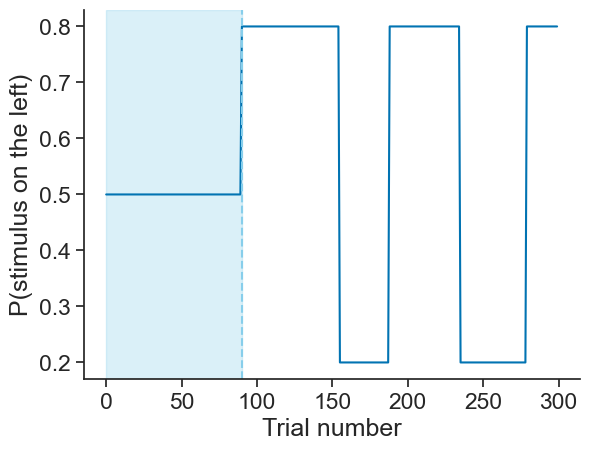

In [233]:
# Choose example session
sess_ex = '726b6915-e7de-4b55-a38e-ff4c461211d3'
# Subset session trials
trials_sess = trials[trials.session == sess_ex].reset_index()

# Plot
plt.plot(trials_sess["probabilityLeft"][:300])
plt.axvspan(0, 90, color="skyblue", alpha=0.3, label="first 90 trials")
plt.axvline(90, color="skyblue", linestyle="--")

plt.ylabel("P(stimulus on the left)")
plt.xlabel("Trial number")
plt.show()

In  Ashwood et al. (2022)<span id="cite1c"></span><a href="#ref1c">[1c]</a>, only the sessions with less than 10 violations were used. To follow this work, we will now revise the number of violations, defined as trials where the animal made no choice. i.e choice == 0 during the 50-50 trials. For this, we will:
 1) Subset sessions which include 50-50 trials
 2) Exclude sessions with >10 violation trials

In [234]:
# Create a list of ids
sessions_ids = trials.session.unique()

# keep only relevant columns for filtering
df_trials = trials[["session", "probabilityLeft", "choice"]]

# Get which sessions contain exactly {0.2, 0.5, 0.8}
valid_prob_sessions = (
    df_trials.groupby("session")["probabilityLeft"]
      .agg(lambda x: set(x.unique()) == {0.2, 0.5, 0.8})
)

# Compute violations only on 50-50 trials
viol_val = 0
violations = (
    df_trials[df_trials["probabilityLeft"] == 0.5]
    .groupby("session")["choice"]
    .apply(lambda x: (x == viol_val).sum())
)

# Apply both restrictions
valid_sessions = violations[
    (violations < 10) & (violations.index.isin(valid_prob_sessions[valid_prob_sessions == True].index))
].index.tolist()

# Make sure they maintain the order of the original dataset (we don't want scrambled trials)
valid_set = set(valid_sessions)
valid_sessions = [
    s for s in trials["session"].drop_duplicates()
    if s in valid_set
]
print(f"# of sessions before restrictions {len(df_trials.session.unique())}")

# Now we can select only the valid sessions for subsequent analyses
df_trials = trials[
    (trials["session"].isin(valid_sessions)) & (df_trials["probabilityLeft"] == 0.5)
]
print(f"# of sessions after restrictions {len(df_trials.session.unique())}")

# of sessions before restrictions 73
# of sessions after restrictions 56


## 02. Building the design matrix
Now, with the valid sessions, we can compute the design matrix. In our case, we are interested in building a design matrix with three predictors: signed contrast, previous choice and win stay lose shift.

```{figure} ../assets/design_matrix_table.png
:alt: Design matrix
:align: right

```

The first predictor, signed contrast, encodes sensory evidence in 1D. Within this predictor, magnitude reflects strength of evidence and sign encodes direction. The second predictor, previous choice, is a lagged version of current choice, and it reflects serial dependence on decisions. The third predictor, win-stay lose-shift, reflects the interaction between past choice and outcome. If an animal made a decision and it was rewarded in a previous trial, then the predictor indicates to "stay". That is, to repeat that choice. Conversely, if the previous choice was not rewarded, then the predictor indicates to "switch" to the other alternative.

Let's go through the process of building the design matrix with one session.

In [235]:
# Select an example session
example_session_id = valid_sessions[0]  
df_example_session = df_trials[df_trials["session"] == example_session_id]

# We can select all the necessary values for the design matrix: 
# choice, contrast of stimuli and reward
choices = df_example_session['choice'].reset_index(drop=True)
stim_left = df_example_session['contrastLeft'].reset_index(drop=True)
stim_right = df_example_session['contrastRight'].reset_index(drop=True)
rewarded = df_example_session['feedbackType'].reset_index(drop=True)

For the first predictor: signed contrast.

In [236]:
# Create stim vector
stim_left = np.nan_to_num(stim_left, nan=0)
stim_right = np.nan_to_num(stim_right, nan=0)

# now get 1D stim
signed_contrast = stim_left - stim_right
print(signed_contrast)

[ 1.     -1.     -0.25    0.     -0.125  -0.0625 -0.0625  0.25   -0.125
 -0.125   0.25   -0.0625 -0.125  -0.125   0.25    1.      0.     -0.25
  1.     -0.25    0.125  -0.0625 -1.     -0.125  -0.0625  0.125  -0.25
  0.25   -0.0625 -0.0625  0.      0.25    0.125   0.0625 -1.      0.125
  0.125   0.     -0.0625  0.0625 -0.125  -0.25   -1.      0.0625  0.0625
  0.0625  0.25    0.125  -0.125  -0.25   -0.125   0.      0.      0.125
 -0.0625  0.0625  1.      0.0625 -0.125   0.125   0.0625 -0.0625  0.
 -0.0625  1.      0.0625  0.125  -0.25    0.0625  1.      0.0625  0.125
  0.125   0.      0.0625 -1.      0.25   -0.0625  1.      0.      0.
  1.      0.0625 -1.      0.25    0.0625 -0.25    0.25    1.     -0.25  ]


In [237]:
# Get rid of violation trials
valid_choices_idx = np.where(~choices.isin([viol_val]))[0]

With those two elements we can compute our design matrix for this session. We will do this using the NeMoS basis class ```nmo.basis```, which will make the process a lot easier.

A basis is a collection of functions that, when combined, can represent more complex relationships. NeMoS has a lot of different basis functions, but here we are interested in using two: ```HistoryConv``` and ```IdentityEval```.

- ```HistoryConv``` includes the history of the samples as predictor. It is intended to be used for including raw history as predictor. You can decide how much history in the past you want to have, but now we only want one choice in the past. We can use this to create the previous choice predictor.

- ```IdentityEval``` includes the samples themselves as predictors. The point of this basis is to make the predictor into a NeMoS object. We can use this for the stimuli predictor. 

It is very easy to declare our basis objects:

In [238]:
# Prev history with history of 1
prev_choice_basis = nmo.basis.HistoryConv(1)
# Identity basis for stimuli
stimuli_basis = nmo.basis.IdentityEval()

However, we are still missing one predictor: win-stay lose-shift. This is an interaction of previous choice with previous reward. To capture interaction between variables, we can use a [multiplicative basis object - PENDING](), which takes the outer product of the elements that compose it.

In [239]:
# Create lagged reward predictor
prev_reward_basis = nmo.basis.HistoryConv(1)

# Create multiplicative basis object
wsls_basis = prev_choice_basis*prev_reward_basis

Now we have all our bases. We can create an additive basis including all of them and then all we need to do now is to apply the basis transformation to the input data. We can do this by using ```compute_features```. This method is designed to be a high-level interface for transforming input data using the basis functions. 

Even though we need just a few lines of code, there is a lot going on. Here's a breakdown of what is happening:
1. We will create an additive basis ```basis_object``` with our bases ```stimuli_basis```, ```wsls_basis``` and ```prev_choice_basis```. 
2. ```wsls_basis``` is a multiplicative basis that takes two inputs.
3. We will compute the features for our ```basis_object``` using ```compute_features```. Since the bases in our composite basis take a total of 4 inputs (```stimuli_basis``` takes 1 input, ```wsls_basis``` takes 2 inputs and ```prev_choice_basis``` takes 1 input), we need to pass 4 features to ```compute_features```.

In [240]:
# Create a composite basis using our three basis
basis_object = (
    stimuli_basis +                         # will process one input
    wsls_basis +                            # will process two inputs (choice & reward)
    prev_choice_basis                       # will process one input
)

# Compute features
X_unnormalized = basis_object.compute_features(
    signed_contrast[valid_choices_idx],     # input 1 : processed with stimuli_basis
    choices[valid_choices_idx],             # input 2 : wsls input 1: choice
    rewarded[valid_choices_idx],            # input 3 : wsls input 2: reward
    choices[valid_choices_idx]              # input 4 : processed with prev_choice
)        

print(X_unnormalized[:5,:])     

[[ 1.       nan    nan]
 [-1.     1.     1.   ]
 [-0.25  -1.    -1.   ]
 [ 0.    -1.    -1.   ]
 [-0.125 -1.    -1.   ]]


And that's it! We have our unnormalized design matrix with signed contrast, win-stay lose-shift and previous choice as predictors.

As as last step, we now need to normalize our signed contrast predictor.

In [241]:
# Normalize across the signed contrast
X = np.copy(X_unnormalized)
X[:, 0] = zscore(X[:, 0])

```{admonition} "Why do we normalize our stimuli predictor?" 
:class: question
:class: dropdown
When fitting a GLM-HMM, we are fitting a separate weight for each feature. However, if the features are on different numerical scales for reasons that are not related to the actual influence of each predictor, that renders the weights incomparable. Here we have three predictors:  
- (1) Previous choice and (2) WSLS are always exactly −1 or +1. Their values are discrete and bounded, and they already share the same scale.
- (3) Stimuli contrast is continuous. While it can reach −1 or +1 (full contrast), this value rarely occurs. 

Because the stimuli contrast values are much smaller in typical magnitude than +/-1, the model compensates by assigning a larger weight to match the output scale, simply because its values are numerically smaller. In practice, this results in an artifact of scale that is not reflective of the  true influence of the predictor.

By normalizing, we are rescaling the predictor to have mean 0 and standard deviation of 1. Previous choice and WSLS already on a unit scale by construction — their values are symmetric around zero and their spread is naturally 1. This is why we only normalize signed contrast.
```

and see our design matrix.

In [242]:
def plot_design_matrix():
    fig, axes = plt.subplots(
        1, 
        2, 
        figsize=(3.5, 8), 
        sharey=True,
    )

    # ---- define signed contrast bins 

    cmap_cat = LinearSegmentedColormap.from_list(
        "bias_map",
        ["#377eb8", "white", "#4daf4a"]  # left → neutral → right
    )

    # ---- heatmap 1: full design matrix ----
    sns.heatmap(
        X[:20,:],
        ax=axes[0],
        square=True,
        cmap=cmap_cat,
        cbar=False,
        vmin=-2.4,
        vmax= 2.4
    )

    axes[0].set_xticks([0.5, 1.5, 2.5],
                    ["Sign. contr.", "WSLS", "Prev. choice",], 
                    rotation=90)
    axes[0].set_yticks([])
    axes[0].set_ylabel("Trials")
    axes[0].set_title("Design \nmatrix")

    # ---- heatmap 2: choices ----
    sns.heatmap(
        choices[valid_choices_idx].to_numpy().reshape(-1, 1)[:20],
        ax=axes[1],
        square=True,
        cmap=cmap_cat,
        cbar=True,
        vmin=-2.4,
        vmax= 2.4
    )
    axes[0].set_yticks([])
    axes[1].set_xticks([0.5], 
                    ["Choices"], 
                    rotation=90)

    plt.tight_layout()
    plt.show()

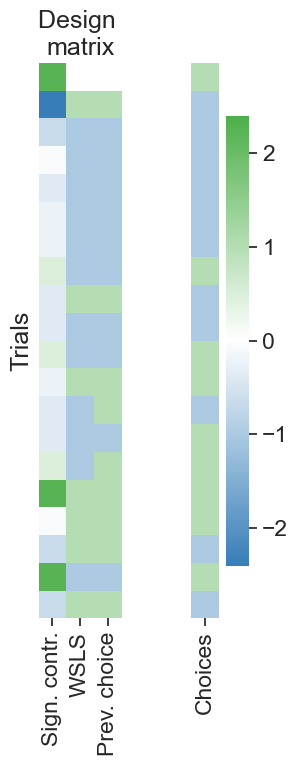

In [243]:
plot_design_matrix()

Similarly, we can do this process for all the sessions

In [244]:
# Subset all relevant data
stim_left = df_trials['contrastLeft'].reset_index(drop=True)
stim_right = df_trials['contrastRight'].reset_index(drop=True)
rewarded = df_trials['feedbackType'].reset_index(drop=True)
choices = df_trials['choice'].reset_index(drop=True).to_numpy()
session = df_trials['session'].reset_index(drop=True).to_numpy()

# Select valid choices
valid_choices_idx = np.where(~(choices == viol_val))[0]

# Create stim vector
stim_left = np.nan_to_num(stim_left, nan=0)
stim_right = np.nan_to_num(stim_right, nan=0)

# now get 1D stim
signed_contrast = stim_left - stim_right
print(signed_contrast)

# Create basis objects
prev_choice_basis = nmo.basis.HistoryConv(1)
prev_reward_basis = nmo.basis.HistoryConv(1)
stimuli_basis = nmo.basis.IdentityEval()

wsls = prev_choice_basis*prev_reward_basis

# Create a composite basis using our three basis
basis_object = (
    stimuli_basis +                         # will process one input
    wsls_basis +                            # will process two inputs (choice & reward)
    prev_choice_basis                       # will process one input
)

# Compute features
X_unnormalized = basis_object.compute_features(
    signed_contrast[valid_choices_idx],     # input 1 : processed with stimuli_basis
    choices[valid_choices_idx],             # input 2 : wsls input 1: choice
    rewarded[valid_choices_idx],            # input 3 : wsls input 2: reward
    choices[valid_choices_idx]              # input 4 : processed with prev_choice
)   

# And then normalize across the signed contrast
X = np.copy(X_unnormalized)
X[:, 0] = zscore(X[:, 0])

# For fitting a Bernoulli, our variables need to be in 0-1 space. So we will remap them so 1: Left and 0: Right
choices = np.where(choices == -1, 0, choices)

[ 1.     -1.     -0.25   ... -1.      0.     -0.0625]


Importantly, do not do 3000 trials at once! Instead, they generally do several sessions of 100-300 trials, and we use all the sessions together to fit our model. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute all sessions as if they were one. 


In NeMoS we have two ways of indicating the beginning of a new session. You can use a Pynapple Tsd or TsdFrame to demarcate sessions, in which case session demarcations are inherited from the pynapple objects. Alternatively, when using a design matrix and a choice vector that are Numpy objects, it is necessary to pass a session indicator. This can be:
- a boolean array or integer array of 1s and 0s indicating session starts, shape ``(n_samples,)``
- an integer array of indices marking session starts, shape ``(n_sessions,)``
- a pynapple.IntervalSet marking session epochs (requires either X or y to be a pynapple Tsd or TsdFrame to get timestamps)

In [245]:
# Mark where session changes
new_sess_mouse = np.ones(len(session), dtype=int)
new_sess_mouse[1:] = (session[1:] != session[:-1])

## 03. Fitting a GLM-HMM with NeMoS (Maximum Likelihood)
We will use a Bernoulli GLM to model this mouse's choices. For this, we first need to initialize the ```GLMHMM``` object. The only required parameter is the number of states. Ashwood et al. (2022) <span id="cite1d"></span><a href="#ref1d">[1d]</a> found that most mice used 3 decision-making states when performing this task. Following that work, we will initialize our ```GLMHMM``` object with 3 states.

```{admonition} GLM-HMM observation models
:class: note

The default observation model for the GLM-HMM is Bernoulli, but Categorical (Multinomial), Poisson, Gamma, Negative Binomial and Gaussian observation models are also available. If you want, you can also set a different observation model of your choice and personalize the inverse link function. However, bear in mind that convexity is not guaranteed for all likelihood functions.

For more information, refer to Escola et al (2011)<span id="cite4"></span><a href="#ref4">[4]</a> and also to [our notebook on GLM-HMM theoretical underpinnings - PENDING]().
```
____

[PENDING - do not edit because it might change]()
If required, you can further personalize the ```GLMHMM``` object settings. Beyond the number of states, the observation model and the inverse link function, you can also initialization functions for to aid parameter estimation. 

If you don't set up any initialization settings, you would use the NeMoS defaults:
- ``"glm_params_init"``: ``"random"`` - small random coefficients, mean-rate intercept
- ``"scale_init"``: ``"constant"`` - scale initialized to 1.0
- ``"initial_proba_init"``: ``"uniform"`` - equal probability for all states
- ``"transition_proba_init"``: ``"sticky"`` - high self-transition probability (0.95)

In [246]:
n_states = 3

model = nmo.glm_hmm.GLMHMM(
    n_states,
    regularizer = "Ridge")

print(model)

GLMHMM(
    n_states=3,
    observation_model=BernoulliObservations(),
    inverse_link_function=logistic,
    regularizer=Ridge(),
    regularizer_strength=1.0,
    solver_name='LBFGS',
    maxiter=1000,
    tol=1e-08,
    initialization_funcs={'glm_params_init': <function random_glm_params_init at 0x12b781620>, 'glm_params_init_kwargs': {}, 'glm_params_init_custom': False, 'scale_init': <function constant_scale_init at 0x12b781b20>, 'scale_init_kwargs': {}, 'scale_init_custom': False, 'initial_proba_init': <function uniform_initial_proba_init at 0x12b6ebe20>, 'initial_proba_init_kwargs': {}, 'initial_proba_init_custom': False, 'transition_proba_init': <function sticky_transition_proba_init at 0x12b6eb600>, 'transition_proba_init_kwargs': {}, 'transition_proba_init_custom': False}
)


```{admonition} "Importance of initial parameters in GLM-HMMs"
:class: question
:class: dropdown
When fitting a GLM-HMMs, the likelihood surface is non-convex, and EM-based fitting can converge to different local optima depending on starting values. As a result, different initializations can lead to qualitatively different parameters. In practice, this makes it necessary to either run multiple random restarts or use informed initializations derived from simpler models (e.g. logistic regression or clustering of behavior).

For a more detailed example of how initialization affects convergence and interpretation, refer to [our notebook on GLM-HMM theoretical underpinnings - PENDING]()
```

Once we created our object, we can fit our model. The fit function takes two mandatory arguments: the design matrix ```X```we created in section 02 and the ```choices```. Additionally, we will also include ```new_sess_mouse```, the new session indicator.

In [247]:
model.fit(X, 
          choices,
          is_new_session=new_sess_mouse
)

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...t 0x12acf6020>
,regularizer,Ridge()
,regularizer_strength,1.0
,dirichlet_initial_proba,None
,dirichlet_transition_proba,None
,solver_name,'LBFGS'
,solver_kwargs,{}
,maxiter,1000
,tol,1e-08


Thats all it takes!

## 04. Interpreting the fitting results

### 04.0 How to see the fitted parameters

In [248]:
permutation = jnp.array([1, 2, 0])
model.coef_ = model.coef_[:, permutation]
model.intercept_ = model.intercept_[permutation]
model.transition_prob_ = model.transition_prob_[permutation][:, permutation]

If we want to see our glm-hmm weights, we can call ```model.coef_```. This will output the coefficients of the glm per state, with shape (n_features, n_states).

In [249]:
print(f"glm weights shape \n {model.coef_.shape} \n")
print(f"glm weights \n {model.coef_}")

glm weights shape 
 (3, 3) 

glm weights 
 [[ 6.09394937  1.54392282  1.59551361]
 [ 0.09838097  0.28090874  0.32669866]
 [ 0.11744862 -0.31349826  0.41747942]]


Similarly, to see the intercept, we can call ```model.intercept_```, which will output the intercept per state. The shape of this object is (n_states)

In [250]:
print(f"intercept shape \n {model.intercept_.shape} \n")
print(f"intercept \n {model.intercept_}")

intercept shape 
 (3,) 

intercept 
 [ 0.02520763  2.7422263  -2.19886003]


We can also see the estimated transition matrix with ```model.transition_prob``` and the initial probatilities with ```model.initial_prob```, with shapes (n_states, n_states) and (n_states,), respectively.

In [251]:
print(f"transition matrix shape \n {model.transition_prob_.shape}")
print(f"transition matrix \n {model.transition_prob_}")

print(f"initial probabilities shape \n {model.initial_prob_.shape}")
print(f"initial probabilities \n {model.initial_prob_}")

transition matrix shape 
 (3, 3)
transition matrix 
 [[0.9821648  0.01077837 0.00705683]
 [0.03769394 0.95279214 0.00951391]
 [0.04070706 0.00320727 0.95608567]]
initial probabilities shape 
 (3,)
initial probabilities 
 [0.23418953 0.64979406 0.11601641]


Let's see what type of information we can gather.

### 04.1 Interpreting the GLM weights
We can plot the GLM weights obtained for our 3-state model.

In [252]:
def plot_glm_weights(model, n_states = n_states):
    plt.figure(figsize=(6, 5))
    colors = ["#ff7f00",  "#4daf4a","#377eb8"]

    n_features = model.coef_.shape[0]+1 # add 1 for the intercept

    # Change order of weights so output matches Ashwood et al. (2022) 2e plot
    recovered_weights = np.zeros((n_features,n_states)) 
    recovered_weights[0,:] = model.coef_[0,:] # stimulus
    recovered_weights[1,:] = model.intercept_ # bias
    recovered_weights[2,:] = model.coef_[2,:] # prev choice, wsls
    recovered_weights[3,:] = model.coef_[1,:] # prev choice, wsls

    # Labels
    X_labels = ["Stimulus", "Bias", "Prev.choice", "WSLS"]

    state_labels = [
        'State 1: "engaged"',
        'State 2: "biased left"',
        'State 3: "biased right"'
    ]

    for state in range(n_states):
        plt.plot(
            range(n_features),
            recovered_weights[:, state],
            color=colors[state],
            marker="o",
            lw=1.5,
            label=state_labels[state],
            linestyle="-",
        )
            
    plt.yticks([-2.5, 0, 2.5, 5])
    plt.ylabel("GLM weight")
    plt.xlabel("Covariate")
    plt.xticks([i for i in range(n_features)], X_labels, fontsize=12, rotation=45)
    plt.axhline(y=0, color="k", alpha=0.5, ls="--")

    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return None

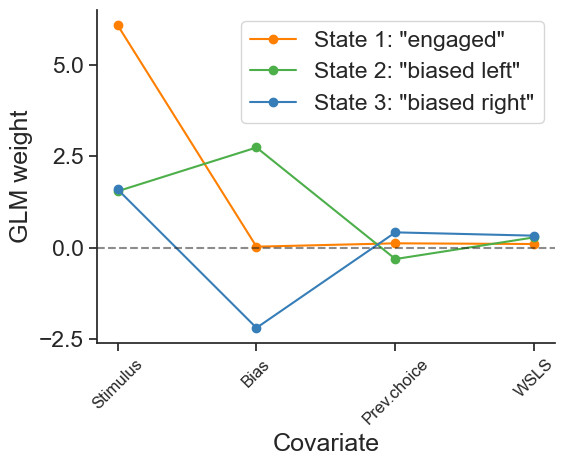

In [253]:
plot_glm_weights(model)

We can see that the coefficients on state 1 have a large weight on the stimulus and low weight on the other predictors. Conversely, in states 2 and 3, the stimulus coefficient is comparatively lower. State 2 has a large positive weight on bias, while State 3 has a large negative weight on bias. Since the sign of our predictors indicates the side of evidence (>0 : left; <0 : right, see the table of variables in section 01) and their magnitude indicates the strength of such evidence, State 2 coefficients suggest a large bias towards leftward choice, while State 3 coefficients suggest a large bias to a rightward choice. All states have similarly low coefficients for prev. choice and wsls, with State 1 showing the smallest of them. 

As a reminder, the task consisted on indicating whether the stimulus was located at the right or the left of the screen using the stimulus contrast information. Thus, the optimal strategy is to maximally use stimulus contrast to guide decision making, and not rely on bias, previous choice or wsls.

### 04.2 Interpreting the transition matrix
We can also see the fitted transition matrix for our three-state model. This describes the transition probabilities among the different states, each corresponding to a different decision-making strategy. Large entries in the diagonal indicate a high probability of remaining in the same state for multiple trials in a row.

In [254]:
def plot_transition_matrix(model, n_states= n_states):
    fig = plt.figure(figsize=(8, 3))
    n_decimals = 3
    # Plot matrix colors
    plt.imshow(model.transition_prob_, vmin=-0.8, vmax=1, cmap='bone')

    # Write probabilities
    for i in range(n_states):
        for j in range(n_states):
            text = plt.text(j, i, str(np.around(model.transition_prob_[i, j], decimals=n_decimals))[:n_decimals+2], ha="center", va="center",
                            color="k")
    plt.xlim(-0.5, n_states - 0.5)
    plt.xticks(range(0, n_states), ('1', '2', '3'))
    plt.xlabel("State t")

    plt.yticks(range(0, n_states), ('1', '2', '3'))
    plt.ylim(n_states - 0.5, -0.5)
    plt.ylabel("State t-1",)

    plt.title("Transition matrix")
    plt.subplots_adjust(0, 0, 1, 1)
    plt.show()
    return None

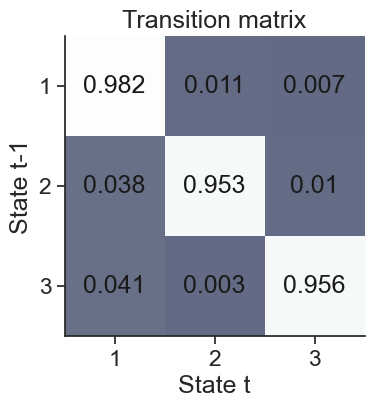

In [255]:
plot_transition_matrix(model)

### 04.3 Using ```smooth_proba``` to see and interpret posterior state probabilities
To better understand the temporal structure of decision making behavior, we can compute the probability of being in each state at each trial, conditioned on the entire observed sequence. For this, we can use ```smooth_proba```. This method uses the forward-backward algorithm to incorporate information from past and future observations. It answers to the question: "Given all observations, what is the probability that the system was in state $k$ at time $t$?"

```smooth_proba``` takes two arguments: a design matrix X and the observed neural activity y. The output is either a ```TsdFrame``` or an array of  posterior probabilities, shape ``(n_time_points, n_states)``. Each row sums to 1 and represents the probability distribution over states at that time point.

In [256]:
# Compute smooth_proba
posteriors = model.smooth_proba(
    X, 
    choices,
    is_new_session=new_sess_mouse
)
print(f"First five osteriors \n{posteriors[:5]} \n")

# Each (non nan) row sums to 1
valid = ~np.isnan(posteriors).any(axis=1)
print(
    f"Each row sums to 1: {np.allclose(posteriors[valid].sum(axis=1), 1)}"
)

First five osteriors 
[[           nan            nan            nan]
 [7.53644282e-01 6.20036090e-02 1.84352109e-01]
 [8.15239194e-01 7.34753446e-03 1.77413271e-01]
 [8.34381257e-01 7.71574040e-04 1.64847169e-01]
 [8.60860382e-01 1.23379741e-04 1.39016238e-01]] 

Each row sums to 1: True


And we can plot it!

In [277]:

def plot_posteriors(posteriors):
    # Pick three sessions to plot
    sess_to_plot = [
        '0ccee376-2873-47dd-9293-c19e424c1bee',
        '66f20f92-171f-4cc5-aca9-69fc3cb6370f',
        '19f4acbd-aeac-4f83-9f30-85a8aa002820'
    ]

    # Get these sessions' indexes
    sess_ex_1 = np.where(session == sess_to_plot[0])[0]
    sess_ex_2 = np.where(session == sess_to_plot[1])[0]
    sess_ex_3 = np.where(session == sess_to_plot[2])[0]

    sess_examples = [sess_ex_1, sess_ex_2, sess_ex_3]

    colors =["#ff7f00", "#4daf4a", "#377eb8"]
    fig, ax = plt.subplots(1,3,figsize=(20, 4))

    for i, sess_ex in enumerate(sess_examples):
        for state in range(n_states):
            # Plot all trials for a given session and state
            ax[i].plot(
                posteriors[sess_ex][:, state],
                label="State " + str(state + 1), 
                lw=3,
                color=colors[state]
    )
            ax[i].set_title("Example session " + str(i + 1))
            if i == 0:
                ax[i].set_xticks(
                    [
                        0, 
                        45, 
                        90
                    ], 
                    [
                        "0", 
                        "45", 
                        "90"
                    ], 
                )
                ax[i].set_ylabel("P(state)")
                ax[i].set_xlabel("Trial #")
                ax[i].set_yticks(
                    [0, 0.5, 1], 
                    ["0", "0.5", "1"], 
                )
            else:
                ax[i].set_xticks(
                    [
                        0, 
                        45, 
                        90
                    ], 
                    [
                        " ", 
                        " ", 
                        " "
                    ], 
                )
                ax[i].set_yticks(
                    [0, 0.5, 1], 
                    [" ", " ", " "], 
                )
    return None

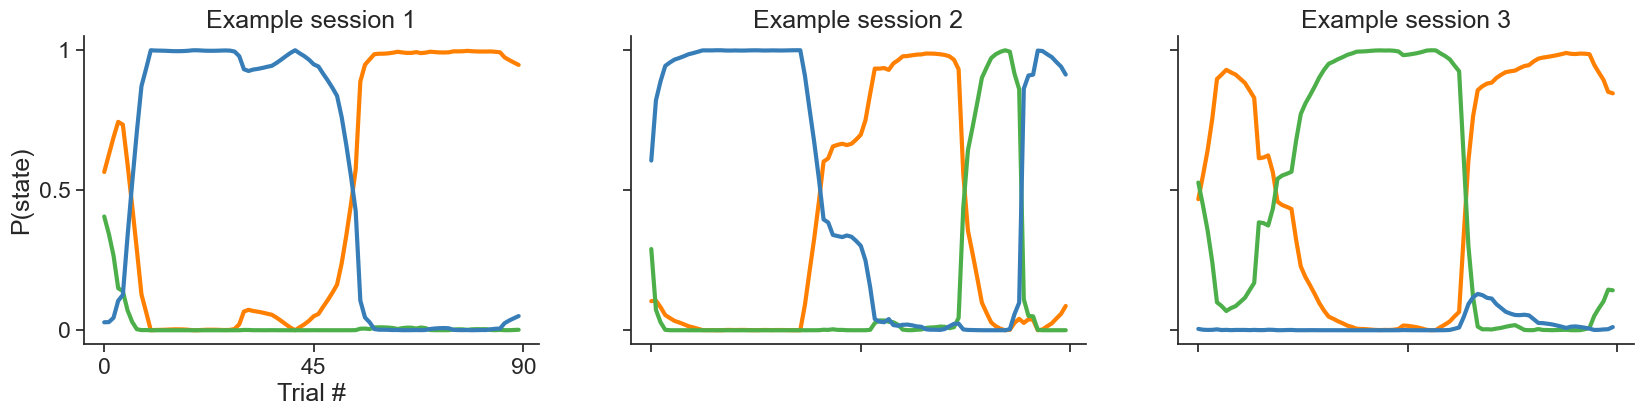

In [278]:
plot_posteriors(posteriors)

In these sessions, the posterior over latent states can be tracked at each trial, revealing strong confidence in state assignments and extended periods where a single state persists across consecutive trials. This pattern is inconsistent with the short, transient lapses assumed in lapse-based models.

### 04.4 Computing fraction of occupancy and accuracy per state using ```decode_state``` or ```smooth_proba```

We can also be interested in quantify state occupancies (i.e what proportion of the trials a given animal spent in each state) and accuracies per state. For this, we need the inferred sequence of states, and there are (at least) two ways in which we can obtain it: using ```decode_state``` or using ```smooth_proba```.

#### 4.4.1) Using ```decode_state```
This method finds the single most likely sequence of hidden states that best explains the observed data. It uses the Viterbi algorithm to compute the state sequence that maximizes the joint probability of states and observations.

This function takes three mandatory parameters, a matrix of predictors X of shape (n_timepoints,n_features), a np.array or nap.Tsd of observations of shap (n_time_points,), and the format of the returned states, either in one-hot encoding format or as an array of shape (n_time_points,) containing the decoded state at each timepoint.

In [259]:
# get output of viterbi in one-hot encoding
decoded_states = model.decode_state(
    X,
    choices,
    is_new_session=new_sess_mouse,
    state_format = "one-hot"
)
print(f"{decoded_states} \n")

# calculate how many instances of occupancy there is in each of them
print(f"Total instances of each state {np.nansum(decoded_states, axis=0)} \n")

# calculate fraction of occupancy
frac_occupancy_viterbi= np.nansum(decoded_states, axis=0)/len(choices)
print(f"Fraction of occupancy {frac_occupancy_viterbi} \n")

[[nan nan nan]
 [ 1.  0.  0.]
 [ 1.  0.  0.]
 ...
 [ 0.  0.  1.]
 [ 0.  0.  1.]
 [ 0.  0.  1.]] 

Total instances of each state [3556.  776.  707.] 

Fraction of occupancy [0.70555556 0.15396825 0.14027778] 



Now, we can compute the general accuracy.

In [260]:
# See where the input is not 0
non_zero_contrast_loc = np.where(signed_contrast!=0)
non_zero_contrast = signed_contrast[non_zero_contrast_loc]

# Get correct answer by looking at sign
correct_ans_task = np.sign(non_zero_contrast)

# Transform into 0-1 to compare with choices
correct_ans_task_remapped = (correct_ans_task+ 1) / 2

# Get accuracy i.e how many choices match / how many choices were made
correct_ans_mouse = np.sum(choices[non_zero_contrast_loc] == correct_ans_task_remapped) 

total_accuracy = correct_ans_mouse/len(correct_ans_task)

# Create array of accuracies for plotting
accuracies_to_plot_viterbi = np.zeros([4,])

# Add total accuracy
accuracies_to_plot_viterbi[0] = total_accuracy

And then we can use our output of ```decode_state``` to segment the trials into the estimated states and compute the accuracy within each state.

In [261]:
for state in range(n_states): 
    # index of trials per state
    idx_this_state = np.where(decoded_states[:,state] == 1)
    
    # Get contrast and choices for this state
    signed_contrast_this_state = signed_contrast[idx_this_state]
    choices_this_state = choices[idx_this_state]
    
    # See where the input is not 0
    not_zero_contrast_loc_this_state = np.where(signed_contrast_this_state != 0)[0]
    non_zero_contrast_this_state = signed_contrast_this_state[not_zero_contrast_loc_this_state]
    
    # Get correct answer by looking at sign
    correct_ans_this_state = np.sign(non_zero_contrast_this_state)
    
    # Transform into 0-1 to compare with choices
    correct_ans_task_this_state_remapped = (correct_ans_this_state+ 1) / 2

    # Get accuracy i.e how many choices match / how many choices were made
    correct_ans_mouse_this_state = np.sum(choices_this_state[not_zero_contrast_loc_this_state] == correct_ans_task_this_state_remapped) 
    
    accuracy_this_state = correct_ans_mouse_this_state / len(correct_ans_this_state)
    
    # Add state accuracy for plotting
    accuracies_to_plot_viterbi[state+1] = accuracy_this_state

print(accuracies_to_plot_viterbi)

[0.80355936 0.8693308  0.66029412 0.6214876 ]


And we can plot this :)

In [262]:
def plot_accuracy_and_occupancy(frac_occupancy, accuracies_to_plot):
    cols = [
        "#ff7f00", "#4daf4a", "#377eb8", '#f781bf', '#a65628', '#984ea3',
            '#999999', '#e41a1c', '#dede00'
        ]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left: state occupancies
    ax = axes[0]
    for z, occ in enumerate(frac_occupancy):
        ax.bar(z, occ, width=0.8, color=cols[z])
        ax.text(z, occ, f"{occ:.2f}", ha='center', va='bottom', fontsize=10)

    ax.set_ylim(0, 1)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['1', '2', '3'])
    ax.set_yticks([0, 0.5, 1])
    ax.set_xlabel('state')
    ax.set_ylabel('frac. occupancy')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Right: accuracies
    ax = axes[1]
    for z, acc in enumerate(accuracies_to_plot):
        col = 'grey' if z == 0 else cols[z - 1]
        ax.bar(z, acc * 100, width=0.8, color=col)
        ax.text(z, acc * 100 + 1, f"{acc*100:.2f}", ha='center', va='bottom', fontsize=10)

    ax.set_ylim(50, 100)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['All', '1', '2', '3'])
    ax.set_yticks([50, 75, 100])
    ax.set_xlabel('state')
    ax.set_ylabel('accuracy (%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    plt.tight_layout()
    plt.show()
    return None

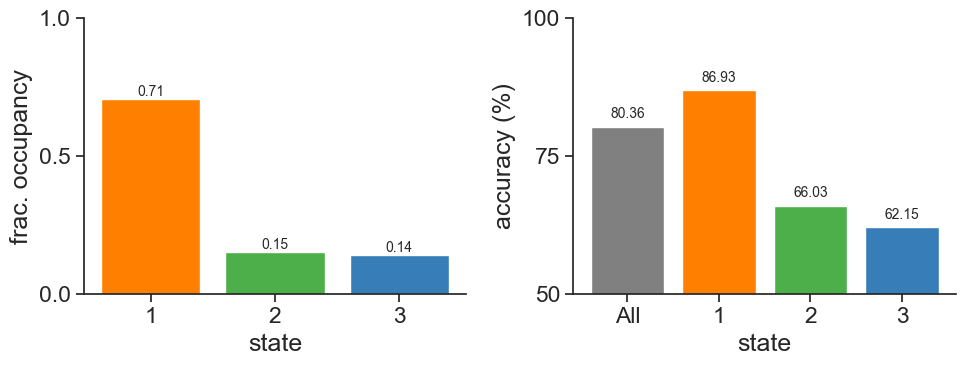

In [263]:
plot_accuracy_and_occupancy(frac_occupancy_viterbi, accuracies_to_plot_viterbi)

According to state occupancy derived with the Viterbi algorithm, this mouse spent the majority of the trials (71%) in the engaged state and a lesser portion of trials in the other two states (29%). We can see that even though this mouse had an overall accuracy of 80.36%, it achieved a higher accuracy of 86.93% in the "engaged" state compared to 66.03% and 62.15% in the "bias left" and "bias right", respectively.

#### 4.4.2) Using ```smooth_proba```
Now we can compute the same quantities but using ```smooth_probs```. We used this method in 4.4 to compute the posterior probabilities! In contrast to ```decode_state```, which outputs the globally optimally state sequence, ```smooth_proba``` outputs probabilistic posteriors. With this alternative, we can go by the approach used in Ashwood et al. (2022): we can compute the posterior probability for each state at all times, and subset the trials for which there is high confidence (+90% probability) of being in a given state; then, we can assign each trial to its most likely state and count the fraction of trials assigned to each state. 

The process is very similar to 4.5.1, with the difference in how we slice the trials and assign them to a specific state. We can start with the fraction of occupancy.

In [264]:
# Get most likely state on a trial by trial basis
states_max_posterior = np.argmax(posteriors, axis=1)
print(f"Most likely state trial by trial \n {states_max_posterior} \n")

# Calculate how many instances of occupancy there is in each of them
occupancy_per_state = np.unique(states_max_posterior, return_counts=True)[1]
print(f"Total instances of each state {occupancy_per_state} \n")

# calculate fraction of occupancy
frac_occupancy_smooth_proba = occupancy_per_state/len(choices)
print(f"Fraction of occupancy {frac_occupancy_smooth_proba } \n")

Most likely state trial by trial 
 [0 0 0 ... 2 2 2] 

Total instances of each state [3450  806  784] 

Fraction of occupancy [0.68452381 0.15992063 0.15555556] 



In [265]:
# Segment trials into states estimated on a trial by trial basis
idx_per_state = []
for state in range(n_states): 
    idx_per_state.append(np.where(posteriors[:, state] >= 0.9)[0])

With this segmentation, we can calculate accuracy in the exact same manner as in 4.4.1.

In [266]:
def get_accuracies_to_plot(idx_per_state, total_accuracy=total_accuracy, n_states=n_states, signed_contrast=signed_contrast, choices=choices):
    # Total accuracy remains the same
    accuracies_to_plot = np.zeros([4,])
    # Use previously calculated total_accuracy
    accuracies_to_plot[0] = total_accuracy
    for state in range(n_states): 
        # index of trials per state
        idx_this_state = idx_per_state[state]

        # Get contrast and choices for this state
        signed_contrast_this_state = signed_contrast[idx_this_state]
        choices_this_state = choices[idx_this_state]
        
        # See where the input is not 0
        not_zero_contrast_loc_this_state = np.where(signed_contrast_this_state != 0)[0]
        non_zero_contrast_this_state = signed_contrast_this_state[not_zero_contrast_loc_this_state]
        
        # Get correct answer by looking at sign
        correct_ans_this_state = np.sign(non_zero_contrast_this_state)
        
        # Transform into 0-1 to compare with choices
        correct_ans_task_this_state_remapped = (correct_ans_this_state+ 1) / 2

        # Get accuracy i.e how many choices match / how many choices were made
        correct_ans_mouse_this_state = np.sum(choices_this_state[not_zero_contrast_loc_this_state] == correct_ans_task_this_state_remapped) 
        
        accuracy_this_state = correct_ans_mouse_this_state / len(correct_ans_this_state)
        
        # Add state accuracy for plotting
        accuracies_to_plot[state+1] = accuracy_this_state
    return accuracies_to_plot

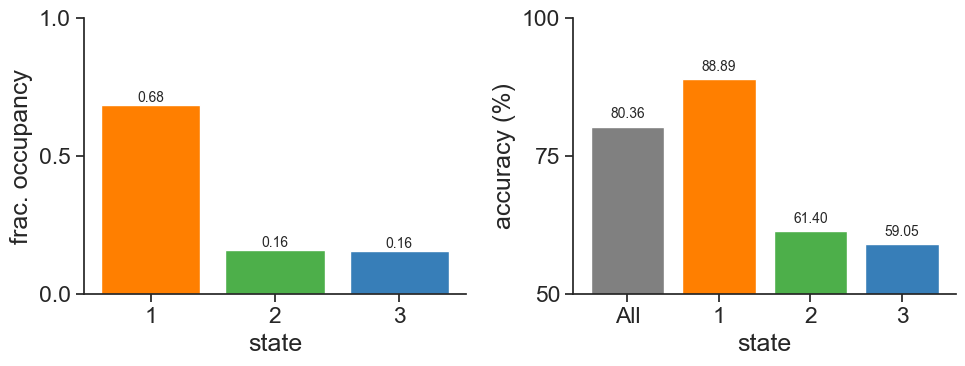

In [267]:
accuracies_to_plot_smooth_proba = get_accuracies_to_plot(idx_per_state)

plot_accuracy_and_occupancy(frac_occupancy_smooth_proba,accuracies_to_plot_smooth_proba)

According to state occupancy derived by using the most likely state with the posterior distribution on a trial by trial basis, this mouse spent the majority of the trials (68%) in the engaged state and a lesser portion of trials in the other two states (32%). We can see that even though this mouse had an overall accuracy of 80.36%, it achieved a higher accuracy of 88.89% in the "engaged" state compared to 61.40% and 59.05% in the "bias left" and "bias right", respectively.

Here, we obtained different results than in 4.4.1. This can be explained by the use of different algorithms for segmenting the trials. While Viterbi finds the most likely sequence of states as a whole, the method in 4.5.1 calculates what the most likely state is on a trial by trial basis, and only keeps the state with large confidence (>90%).

## 05. Conclusion
We showed how to download and preprocess mice data from the IBL, how to create a design matrix and use it to fit choice data using a GLM-HMM, and how to interpret the results.

Using basis objects, we created a design matrix with three predictors: stimulus, previous choice and WSLS. Using NeMoS, this just took a few lines of code:
```
prev_choice_basis = nmo.basis.HistoryConv(1)
stimuli_basis = nmo.basis.IdentityEval()
prev_reward_basis = nmo.basis.HistoryConv(1)

# Multiplicative basis: interaction between prev. choice and reward
wsls_basis = prev_choice_basis*prev_reward_basis

# Additive basis using our three basis
basis_object = (
    stimuli_basis +                         # will process one input
    wsls_basis +                            # will process two inputs (choice & reward)
    prev_choice_basis                       # will process one input
)

# Compute features
X_unnormalized = basis_object.compute_features(
    signed_contrast[valid_choices_idx],     # input 1 : processed with stimuli_basis
    choices[valid_choices_idx],             # input 2 : wsls input 1: choice
    rewarded[valid_choices_idx],            # input 3 : wsls input 2: reward
    choices[valid_choices_idx]              # input 4 : processed with prev_choice
)           
```
Similarly, the fitting process using NeMoS was also very fast and easy:
```
n_states = 3

model = nmo.glm_hmm.GLMHMM(
    n_states,
    regularizer = "Ridge")

model.fit(X, 
          np.asarray(choices),
          is_new_session=new_sess_mouse
)
```
After fitting, we saw that across sessions, behavior could be described as a mixture of a small number of latent strategies that persist over multiple trials rather than independent lapses around a single policy. This is visible in the inferred posterior trajectories and in the Viterbi-decoded state sequences, which show extended dwell times within states. State occupancy and performance analyses further showed that behavioral accuracy is not uniform across latent states. The stimulus-driven state yields higher task-aligned performance, while biased states show reduced accuracy, consistent with reduced sensitivity to sensory evidence.

## Additional resources [pending]
- [NeMoS background on GLM-HMMs - Pending]()
- [Bishop (2006) Chapter 13 "Sequential Data"](https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf): Specially section 13.2, "Hidden Markov Models", provides an overview of MLE for HMMs, the forward-backward algorithm and the viterbi algorithm.
- [Zoe Ashwood's SSM tutorial on GLM-HMMs](https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb): this educational notebook explains GLM-HMMs and fitting with MLE and MAP.
- [GLM-HMMs blogpost by Camila Ucheoma](https://anneurai.net/2024/01/26/a-glm-hmm-deep-dive/): this blogpost provides a summary of Ashwood et al. (2022) work and a brief explanation of GLM-HMMs

## References
<a id="ref1a"><a href="#cite1a">[1a]</a> <a id="ref1b"><a href="#cite1b">[1b]</a> <a id="ref1c"><a href="#cite1c">[1c]</a> <a id="ref1d"><a href="#cite1d">[1d]</a> <a id="ref1e"><a href="#cite1e">[1e]</a> [Ashwood, Z. C., Roy, N. A., Stone, I. R., Laboratory, I. B., Urai, A. E., Churchland, A. K., Pouget, A., & Pillow, J. W. (2022). Mice alternate between discrete strategies during perceptual decision-making. Nature Neuroscience, 25(2), 201–212.](https://doi.org/10.1038/s41593-021-01007-z)

<a id="ref2a"><a href="#cite2a">[2a]</a><a id="ref2b"> <a href="#cite2b">[2b]</a> <a id="ref2c"><a href="#cite2c">[2c]</a> [The International Brain Laboratory, Aguillon-Rodriguez, V., Angelaki, D., Bayer, H., Bonacchi, N., Carandini, M., Cazettes, F., Chapuis, G., Churchland, A. K., Dan, Y., Dewitt, E., Faulkner, M., Forrest, H., Haetzel, L., Häusser, M., Hofer, S. B., Hu, F., Khanal, A., Krasniak, C., … Zador, A. M. (2021). Standardized and reproducible measurement of decision-making in mice. eLife, 10, e63711.](https://doi.org/10.7554/eLife.63711)

<a id="ref3"><a href="#cite3">[3]</a> [Burgess, C. P., Lak, A., Steinmetz, N. A., Zatka-Haas, P., Bai Reddy, C., Jacobs, E. A. K., Linden, J. F., Paton, J. J., Ranson, A., Schröder, S., Soares, S., Wells, M. J., Wool, L. E., Harris, K. D., & Carandini, M. (2017). High-Yield Methods for Accurate Two-Alternative Visual Psychophysics in Head-Fixed Mice. Cell Reports, 20(10), 2513–2524.](https://doi.org/10.1016/j.celrep.2017.08.047)

<a id="ref4"><a href="#cite4">[4]</a> [Escola, S., Fontanini, A., Katz, D., & Paninski, L. (2011). Hidden Markov models for the stimulus-response relationships of multistate neural systems. Neural Computation, 23(5), 1071–1132.](https://doi.org/10.1162/NECO_a_00118)

<a id="ref5"><a href="#cite5">[5]</a> [Bishop, C. M. (2006). Pattern recognition and machine learning. Springer.](https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)